##Importação dos Datasets


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('train.csv')
print(df.head(15))

                  id                                       comment_text  \
0   0000997932d777bf  Explanation\nWhy the edits made under my usern...   
1   000103f0d9cfb60f  D'aww! He matches this background colour I'm s...   
2   000113f07ec002fd  Hey man, I'm really not trying to edit war. It...   
3   0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...   
4   0001d958c54c6e35  You, sir, are my hero. Any chance you remember...   
5   00025465d4725e87  "\n\nCongratulations from me as well, use the ...   
6   0002bcb3da6cb337       COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK   
7   00031b1e95af7921  Your vandalism to the Matt Shirvington article...   
8   00037261f536c51d  Sorry if the word 'nonsense' was offensive to ...   
9   00040093b2687caa  alignment on this subject and which are contra...   
10  0005300084f90edc  "\nFair use rationale for Image:Wonju.jpg\n\nT...   
11  00054a5e18b50dd4  bbq \n\nbe a man and lets discuss it-maybe ove...   
12  0005c987bdfc9d4b  Hey

In [ ]:
print(df.columns)
print(df.shape)

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')
(159571, 8)


In [ ]:
olid = pd.read_csv("olid-training-v1.0.tsv", sep="\t")
print(olid.head(10))


      id                                              tweet subtask_a  \
0  86426  @USER She should ask a few native Americans wh...       OFF   
1  90194  @USER @USER Go home you’re drunk!!! @USER #MAG...       OFF   
2  16820  Amazon is investigating Chinese employees who ...       NOT   
3  62688  @USER Someone should'veTaken" this piece of sh...       OFF   
4  43605  @USER @USER Obama wanted liberals &amp; illega...       NOT   
5  97670                  @USER Liberals are all Kookoo !!!       OFF   
6  77444                   @USER @USER Oh noes! Tough shit.       OFF   
7  52415  @USER was literally just talking about this lo...       OFF   
8  45157                         @USER Buy more icecream!!!       NOT   
9  13384  @USER Canada doesn’t need another CUCK! We alr...       OFF   

  subtask_b subtask_c  
0       UNT       NaN  
1       TIN       IND  
2       NaN       NaN  
3       UNT       NaN  
4       NaN       NaN  
5       TIN       OTH  
6       UNT       NaN  
7   

In [ ]:
print(olid.columns)
print(olid.shape)

Index(['id', 'tweet', 'subtask_a', 'subtask_b', 'subtask_c'], dtype='object')
(13240, 5)


In [ ]:
def classificar(row):
  if row["subtask_a"] == "NOT":
    return "neutro"
  elif row["subtask_b"] == "TIN":
    return "assedio"
  else:
    return "ofensivo"

olid["classe_final"] = olid.apply(classificar, axis=1)
print(olid[["tweet", "classe_final"]].head(10))

                                               tweet classe_final
0  @USER She should ask a few native Americans wh...     ofensivo
1  @USER @USER Go home you’re drunk!!! @USER #MAG...      assedio
2  Amazon is investigating Chinese employees who ...       neutro
3  @USER Someone should'veTaken" this piece of sh...     ofensivo
4  @USER @USER Obama wanted liberals &amp; illega...       neutro
5                  @USER Liberals are all Kookoo !!!      assedio
6                   @USER @USER Oh noes! Tough shit.     ofensivo
7  @USER was literally just talking about this lo...      assedio
8                         @USER Buy more icecream!!!       neutro
9  @USER Canada doesn’t need another CUCK! We alr...      assedio


In [ ]:
data = pd.read_csv("labeled_data.csv")
print(data.head(15))

    Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0            0      3            0                   0        3      2   
1            1      3            0                   3        0      1   
2            2      3            0                   3        0      1   
3            3      3            0                   2        1      1   
4            4      6            0                   6        0      1   
5            5      3            1                   2        0      1   
6            6      3            0                   3        0      1   
7            7      3            0                   3        0      1   
8            8      3            0                   3        0      1   
9            9      3            1                   2        0      1   
10          10      3            0                   3        0      1   
11          11      3            0                   3        0      1   
12          12      3            0    

In [ ]:
print(data.columns)
print(data.shape)


Index(['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither',
       'class', 'tweet'],
      dtype='object')
(24783, 7)


##Padronização dos Datasets

In [ ]:
df = df[['comment_text', 'toxic', 'insult', 'threat', 'obscene', 'identity_hate']]

In [ ]:
olid = olid[['tweet', 'subtask_a']]

In [ ]:
data = data[['tweet', 'class']]

In [ ]:
df = df.rename(columns={
    'comment_text': 'text'
})

olid = olid.rename(columns={
    'tweet': 'text',
    'subtask_a': 'label'
})

data = data.rename(columns={
    'tweet': 'text',
    'class': 'label'
})

In [ ]:
print("DF: ")
print(df.head())

print("\nOLID: ")
print(olid.head())

print("\nDATA: ")
print(data.head())

DF: 
                                                text  toxic  insult  threat  \
0  Explanation\nWhy the edits made under my usern...      0       0       0   
1  D'aww! He matches this background colour I'm s...      0       0       0   
2  Hey man, I'm really not trying to edit war. It...      0       0       0   
3  "\nMore\nI can't make any real suggestions on ...      0       0       0   
4  You, sir, are my hero. Any chance you remember...      0       0       0   

   obscene  identity_hate  
0        0              0  
1        0              0  
2        0              0  
3        0              0  
4        0              0  

OLID: 
                                                text label
0  @USER She should ask a few native Americans wh...   OFF
1  @USER @USER Go home you’re drunk!!! @USER #MAG...   OFF
2  Amazon is investigating Chinese employees who ...   NOT
3  @USER Someone should'veTaken" this piece of sh...   OFF
4  @USER @USER Obama wanted liberals &amp; illega

##Padronização dos Rótulos

Como cada dataset utiliza diferentes sistemas de anotação, foi necessária uma etapa de padronização dos rótulos. Dessa forma, convertemos todas as classes para um problema binário, onde zero representa conteúdo não ofensivo e um representa conteúdo ofensivo. Isso permitiu consolidar os datasets em uma única base comparável.

In [ ]:
df['label'] = (
    df[['toxic', 'insult', 'threat', 'obscene', 'identity_hate']]
    .max(axis=1)   #se qualquer toxicidade existir, vira ofensivo:
)
#manter apenas texto + label
df = df[['text', 'label']]

olid['label'] = olid['label'].map({
    'NOT': 0,
    'OFF': 1
})

data['label'] = data['label'].map({
    2: 0,
    0: 1,
    1: 1
})

In [ ]:
#verificar resultados
print("DF labels: ")
print(df['label'].value_counts())

print("\nOLID labels: ")
print(olid['label'].value_counts())

print("\nDATA labels: ")
print(data['label'].value_counts())

DF labels: 
label
0    143346
1     16225
Name: count, dtype: int64

OLID labels: 
label
0    8840
1    4400
Name: count, dtype: int64

DATA labels: 
label
1    20620
0     4163
Name: count, dtype: int64


In [ ]:
print(df['text'].head())

0    Explanation\nWhy the edits made under my usern...
1    D'aww! He matches this background colour I'm s...
2    Hey man, I'm really not trying to edit war. It...
3    "\nMore\nI can't make any real suggestions on ...
4    You, sir, are my hero. Any chance you remember...
Name: text, dtype: object


#Limpeza de Texto (NLP)

Limpeza textual para remover ruídos que podem prejudicar o desempenho dos modelos. Foram removidos links, pontuações, números, hashtags, menções e palavras irrelevantes, além da conversão dos textos para letras minúsculas e remoção de stopwords.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

In [ ]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#função de limpeza
def limpar_texto(text):

  text = str(text) #garantir que é string

  #normalizar espaços estranhos
  text = text.replace('\xa0', ' ')

  #converter para minúsculo
  text = text.lower()

  #remover URLs
  text = re.sub(r'http\S+|www\S+', ' ', text)

  #remover menções (@usuario)
  text = re.sub(r'@\w+', ' ', text)

  #remover hashtags
  text = re.sub(r'#', ' ', text)

  #remover números
  text = re.sub(r'\d+', ' ', text)

  #remover pontuação
  text = re.sub(r'[^\w\s]', ' ', text)

  #remover espaços extras
  text = re.sub(r'\s+', ' ', text)

  #remover stopwords
  palavras = text.split()
  palavras = [p for p in palavras if p not in stop_words]

  palavras = [p for p in palavras if p not in ['rt', 'amp',]]

  #juntar novamente
  text = ' '.join(palavras)
  return text

In [ ]:
#aplicação nos datasets
df['text'] = df['text'].apply(limpar_texto)
olid['text'] = olid['text'].apply(limpar_texto)
data['text'] = data['text'].apply(limpar_texto)

In [ ]:
print(df['text'].head())

0    explanation edits made username hardcore metal...
1    aww matches background colour seemingly stuck ...
2    hey man really trying edit war guy constantly ...
3    make real suggestions improvement wondered sec...
4                        sir hero chance remember page
Name: text, dtype: object


In [ ]:
print(olid['text'].head())

0                            ask native americans take
1                         go home drunk maga trump url
2    amazon investigating chinese employees selling...
3                   someone vetaken piece shit volcano
4       obama wanted liberals illegals move red states
Name: text, dtype: object


In [ ]:
print(data['text'].head())

0    woman complain cleaning house man always take ...
1    boy dats cold tyga dwn bad cuffin dat hoe st p...
2         dawg ever fuck bitch start cry confused shit
3                                     look like tranny
4       shit hear might true might faker bitch told ya
Name: text, dtype: object


Foi realizada a limpeza textual, incluindo conversão para minúsculas, remoção de URLs, menções, hashtags, pontuação e stopwords, com o objetivo de reduzir ruídos e melhorar a qualidade dos dados para modelagem

#Tokenização

os textos passaram por tokenização, processo responsável por segmentar frases em unidades menores, chamadas tokens.

In [ ]:
def tokenizar(text):
  return text.split()

df['tokens'] = df['text'].apply(tokenizar)
olid['tokens'] = olid['text'].apply(tokenizar)
data['tokens'] = data['text'].apply(tokenizar)

In [ ]:
print(df[['text', 'tokens']].head())

                                                text  \
0  explanation edits made username hardcore metal...   
1  aww matches background colour seemingly stuck ...   
2  hey man really trying edit war guy constantly ...   
3  make real suggestions improvement wondered sec...   
4                      sir hero chance remember page   

                                              tokens  
0  [explanation, edits, made, username, hardcore,...  
1  [aww, matches, background, colour, seemingly, ...  
2  [hey, man, really, trying, edit, war, guy, con...  
3  [make, real, suggestions, improvement, wondere...  
4                [sir, hero, chance, remember, page]  


In [ ]:
print(olid[['text', 'tokens']].head())

                                                text  \
0                          ask native americans take   
1                       go home drunk maga trump url   
2  amazon investigating chinese employees selling...   
3                 someone vetaken piece shit volcano   
4     obama wanted liberals illegals move red states   

                                              tokens  
0                     [ask, native, americans, take]  
1                [go, home, drunk, maga, trump, url]  
2  [amazon, investigating, chinese, employees, se...  
3           [someone, vetaken, piece, shit, volcano]  
4  [obama, wanted, liberals, illegals, move, red,...  


In [ ]:
print(data[['text', 'tokens']].head())

                                                text  \
0  woman complain cleaning house man always take ...   
1  boy dats cold tyga dwn bad cuffin dat hoe st p...   
2       dawg ever fuck bitch start cry confused shit   
3                                   look like tranny   
4     shit hear might true might faker bitch told ya   

                                              tokens  
0  [woman, complain, cleaning, house, man, always...  
1  [boy, dats, cold, tyga, dwn, bad, cuffin, dat,...  
2  [dawg, ever, fuck, bitch, start, cry, confused...  
3                               [look, like, tranny]  
4  [shit, hear, might, true, might, faker, bitch,...  


Foi realizada a tokenização dos textos, segmentando as sentenças em unidades léxicas (tokens), permitindo uma melhor representação textual para etapas posteriores de modelagem

#Vetorização

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#juntando todos os textos
todos_textos = pd.concat([df['text'], olid['text'], data['text']])

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)  #limita o vocabulário
vectorizer.fit(todos_textos)

TfidfVectorizer(max_features=5000)

In [ ]:
#aplicando nos dados
X_df = vectorizer.transform(df['text'])
X_olid = vectorizer.transform(olid['text'])
X_data = vectorizer.transform(data['text'])

In [ ]:
print(X_df.shape)

(159571, 5000)


* 159571 = número de textos
* 5000 = número de palavras (features)

In [ ]:
print(X_olid.shape)

(13240, 5000)


In [ ]:
print(X_data.shape)

(24783, 5000)


Foi aplicada a técnica de vetorização TF-IDF (Term Frequency-Inverse Document Frequency), transformando os textos em representações numéricas, permitindo a utilização de algoritmos de aprendizado de máquina

#Divisão dos dados + Modelo (Baseline)

Os dados foram divididos em conjuntos de treino e teste utilizando a função `train_test_split` da biblioteca Scikit-learn.

- 80% dos dados foram utilizados para treinamento
- 20% dos dados foram utilizados para teste

Essa divisão é importante para avaliar a capacidade de generalização do modelo, garantindo que ele seja capaz de classificar corretamente comentários nunca vistos anteriormente.

O parâmetro `random_state=42` foi utilizado para garantir reprodutibilidade dos resultados.

In [ ]:
#juntando tudo
dados = pd.concat([
    df[['text', 'label']],
    olid[['text', 'label']],
    data[['text', 'label']]
])

In [ ]:
#separando X e y
X = dados['text']
y = dados['label']

In [ ]:
 #treino e teste
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

def treinar_avaliar(modelo, nome):
  modelo.fit(X_train, y_train)
  y_pred = modelo.predict(X_test)

  print(f"\n==== {nome} ====")
  print("Acurácia: ", accuracy_score(y_test, y_pred))
  print(classification_report(y_test, y_pred))

  return y_pred

In [ ]:
X = dados['text']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#aplicando TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

**Modelos**

In [ ]:
#Regressão Logística
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
treinar_avaliar(modelo_lr, "Regressão Logística")


==== Regressão Logística ====
Acurácia:  0.9269465320478757
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     31123
           1       0.80      0.87      0.84      8396

    accuracy                           0.93     39519
   macro avg       0.88      0.91      0.89     39519
weighted avg       0.93      0.93      0.93     39519



array([0, 0, 1, ..., 1, 1, 1])

* Acurácia = o modelo acertou 94% das classificações

Classe 0 (não ofensivo):
* o modelo é quase perfeito em identificar textos normais
* pouquíssimos falsos positivos

Classe 1 (ofensivo):
* quando ele diz que é ofensivo -> geralmente está certo (precision alta)
* mas ele perde alguns casos ofensivos (recall 0.77)
* ele deixa passar alguns comentários ofensivos

Macro vs Weigthed
* há desbalanceamento (mais classe 0 que classe 1)
* o modelo está um pouco melhor na classe majoritária

Os dados foram divididos em conjuntos de treino e teste (80/20). Em seguida, foi aplicado o modelo de Regressão Logística, sendo avaliado por métricas como acurácia, precisão, recall e F1-score

In [ ]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB

modelo_nb = MultinomialNB()
treinar_avaliar(modelo_nb, "Naive Bayes")


==== Naive Bayes ====
Acurácia:  0.9248209721905919
              precision    recall  f1-score   support

           0       0.94      0.97      0.95     31123
           1       0.88      0.75      0.81      8396

    accuracy                           0.92     39519
   macro avg       0.91      0.86      0.88     39519
weighted avg       0.92      0.92      0.92     39519



array([0, 0, 1, ..., 1, 1, 1])

* Acurácia = o modelo acertou aproximadamente 92% das classificações

Classe 0 (não ofensivo):
* o modelo identifica muito bem textos normais (recall 0.97)
* mantém uma boa precisão, com poucos falsos positivos

Classe 1 (ofensivo):
* quando ele diz que é ofensivo -> geralmente está certo (precision 0.88)
* porém, deixa passar alguns casos ofensivos (recall 0.75)
* desempenho um pouco inferior ao da regressãp logística na detecção dessa classe

Macro vs Weigthed
* há desbalanceamento entre as classes
* o modelo mantém desempenho consistente, mas ainda favorece levemente a classe majoritária

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier


modelo_rf = RandomForestClassifier(n_estimators=50, max_depth=20, n_jobs=-1)
treinar_avaliar(modelo_rf, "Random Forest")


==== Random Forest ====
Acurácia:  0.8339532882917078
              precision    recall  f1-score   support

           0       0.83      1.00      0.90     31123
           1       1.00      0.22      0.36      8396

    accuracy                           0.83     39519
   macro avg       0.91      0.61      0.63     39519
weighted avg       0.86      0.83      0.79     39519



array([0, 0, 1, ..., 0, 0, 0])

* Acurácia = o modelo acertou aproximadamente 83% das classificações

Classe 0 (não ofensivo):
* o modelo praticamente classifica todos os textos como não ofensivos (recall 1.00)
* porém, isso indica um viéis forte para essa classe

Classe 1 (ofensivo):
* quando ele identifca como opfensivo, quase sempre acerta (precision 1.00)
* porém, deixa passar muitos casos ofensivos (recall 0.24)
* desempenho muito baixo na detecção dessa classe

Macro vs Weigthed
* há forte desbalanceamento impactando o modelo
* o desempenho geral é prejudicado pela baixa capacidade de identificar a classe ofensiva

#**Análise de Sentimento**

In [ ]:
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

Foi utilizado o **TextBlob** que é uma biblioteca de processamento de linguagem natural que possui um dicionário interno de palavras pré-classificadas. Ele analisa o texto e quantifica o sentimento de acordo com a métrica de:

* **Polaridade:** Varia de `-1.0` (extremamente negativo) a `1.0` (extremamente positivo). O valor `0.0` indica neutralidade.




In [ ]:
#função para calcular sentimento
def analisar_sentimento(texto):

    blob = TextBlob(texto)

    polaridade = blob.sentiment.polarity

    #classificação

    if polaridade > 0:
        sentimento = "positivo"

    elif polaridade < 0:
        sentimento = "negativo"

    else:
        sentimento = "neutro"

    return polaridade, sentimento

#aplicar no dataset principal

dados['polaridade'], dados['sentimento'] = zip(
    *dados['text'].apply(analisar_sentimento)
)

print(dados[['text', 'polaridade', 'sentimento']].head(10))

                                                text  polaridade sentimento
0  explanation edits made username hardcore metal...    0.136364   positivo
1  aww matches background colour seemingly stuck ...    0.250000   positivo
2  hey man really trying edit war guy constantly ...    0.150000   positivo
3  make real suggestions improvement wondered sec...    0.183333   positivo
4                      sir hero chance remember page    0.000000     neutro
5           congratulations well use tools well talk    0.000000     neutro
6                        cocksucker piss around work    0.000000     neutro
7  vandalism matt shirvington article reverted pl...    0.000000     neutro
8  sorry word nonsense offensive anyway intending...   -0.220000   negativo
9               alignment subject contrary dulithgow   -0.166667   negativo


Gráfico

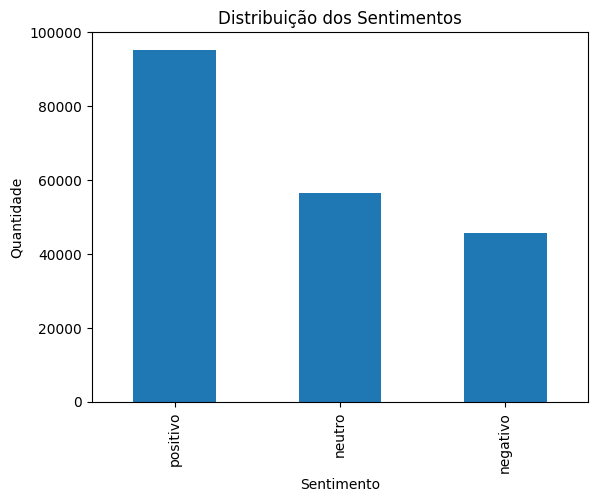

In [ ]:
dados['sentimento'].value_counts().plot(kind='bar')

plt.title("Distribuição dos Sentimentos")
plt.xlabel("Sentimento")
plt.ylabel("Quantidade")

plt.show()

O gráfico apresenta a distribuição dos sentimentos identificados nos comentários analisados pelo modelo de análise de sentimento. Os textos foram classificados em três categorias principais:

- Positivo
- Neutro
- Negativo

Observa-se predominância de sentimentos positivos no conjunto de dados. Em seguida, aparecem os comentários neutros e negativos.

Apesar da maior quantidade de sentimentos positivos, existe uma quantidade significativa de comentários negativos. Esse resultado é relevante para o projeto, pois conteúdos ofensivos, tóxicos ou com discurso de ódio geralmente apresentam polaridade negativa.

A presença de comentários positivos e neutros também é importante para o treinamento do modelo, já que permite ao algoritmo aprender a diferenciar textos ofensivos de comentários comuns, reduzindo vieses e melhorando a capacidade de generalização.

A análise de sentimento foi utilizada como recurso complementar aos algoritmos de Machine Learning, auxiliando na identificação de padrões emocionais associados à toxicidade textual.

Dessa forma, a análise de sentimento contribui para a detecção automática de conteúdos ofensivos ao fornecer informações emocionais relevantes sobre os comentários analisados.

In [ ]:
#comparação entre sentimento e classe

pd.crosstab(
    dados['sentimento'],
    dados['label']
)


label,0,1
sentimento,,
negativo,28868,16863
neutro,43440,13182
positivo,84041,11200


A tabela apresenta a relação entre os sentimentos identificados nos comentários e suas respectivas classificações de toxicidade.

Observa-se que comentários classificados como positivos possuem predominância de conteúdos não ofensivos, indicando coerência entre polaridade positiva e textos normais.

Por outro lado, os comentários com sentimento negativo apresentaram quantidade significativamente maior de conteúdos ofensivos quando comparados proporcionalmente aos demais sentimentos.

Esse comportamento demonstra que sentimentos negativos possuem forte relação com comentários tóxicos e ofensivos, evidenciando que a análise de sentimento pode auxiliar na detecção automática de discurso de ódio.

Entretanto, também é possível observar comentários ofensivos classificados como positivos ou neutros, mostrando que a análise de sentimento, isoladamente, não é suficiente para detectar discurso ofensivo, sendo necessária sua utilização em conjunto com técnicas de Machine Learning e Processamento de Linguagem Natural.

In [ ]:
tabela = pd.crosstab(
    dados['sentimento'],
    dados['label'],
    normalize='index'
) * 100

print(tabela)

label               0          1
sentimento                      
negativo    63.125670  36.874330
neutro      76.719296  23.280704
positivo    88.240359  11.759641


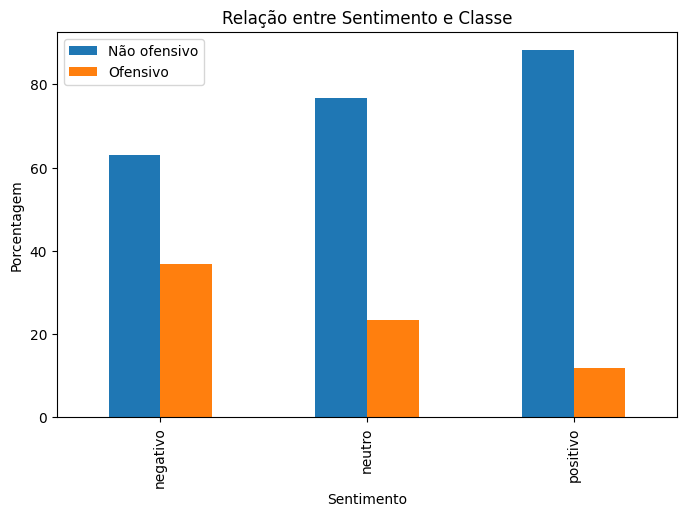

In [ ]:
tabela.plot(kind='bar', figsize=(8,5))

plt.title("Relação entre Sentimento e Classe")
plt.xlabel("Sentimento")
plt.ylabel("Porcentagem")

plt.legend(["Não ofensivo", "Ofensivo"])

plt.show()

O gráfico apresenta a relação entre os sentimentos identificados nos comentários e suas respectivas classificações de toxicidade.

Observa-se que comentários classificados como negativos apresentaram maior proporção de conteúdo ofensivo, com aproximadamente 37% dos textos sendo classificados como ofensivos.

Já os comentários positivos apresentaram predominância de conteúdos não ofensivos, com apenas cerca de 12% dos textos classificados como tóxicos.

Esses resultados indicam que existe relação entre polaridade negativa e discurso ofensivo, mostrando que a análise de sentimento pode auxiliar na identificação automática de conteúdos tóxicos.

Entretanto, também é possível observar comentários ofensivos em categorias positivas e neutras, evidenciando que a análise de sentimento, isoladamente, não é suficiente para detectar discurso de ódio com total precisão.

Dessa forma, a análise de sentimento foi utilizada como recurso complementar aos modelos de Machine Learning, fornecendo informações emocionais relevantes para a classificação textual.

#**Teste do Modelo**

In [ ]:
frases_teste = [
    #Não ofensivas
    "Today is a beautiful day to study.",
    "I disagree with your opinion, but I respect it.",
    "This movie is not very good.",

    #Borderline
    "That was a stupid idea.",
    "You don't know anything about this.",
    "This work is terrible.",

    #Ofensivas
    "You are trash, nobody likes you.",
    "Shut up, you idiot.",
    "You are completely useless.",
    "People like you shouldn't exist.",
    "Go to hell, you incompetent"
]

In [ ]:
def prever_frase(frase):
  frase_transformada = vectorizer.transform([frase])

  previsao = modelo_lr.predict(frase_transformada)
  probabilidade = modelo_lr.predict_proba(frase_transformada)

  prob_ofensivo = probabilidade[0][1]

  rotulo = "Ofensivo" if previsao[0] == 1 else "Não Ofensivo"

  print(f"Frase: {frase}")
  print(f"Classificação: {rotulo}")
  print(f"Probabilidade de ser ofensivo: {prob_ofensivo: .2f}")
  print("-" * 50)

for frase in frases_teste:
  prever_frase(frase)

Frase: Today is a beautiful day to study.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.21
--------------------------------------------------
Frase: I disagree with your opinion, but I respect it.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.13
--------------------------------------------------
Frase: This movie is not very good.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.07
--------------------------------------------------
Frase: That was a stupid idea.
Classificação: Ofensivo
Probabilidade de ser ofensivo:  1.00
--------------------------------------------------
Frase: You don't know anything about this.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.25
--------------------------------------------------
Frase: This work is terrible.
Classificação: Ofensivo
Probabilidade de ser ofensivo:  0.52
--------------------------------------------------
Frase: You are trash, nobody likes you.
Classificação: Ofensivo
Probabilida

In [ ]:
def prever_frase(frase):
  frase_transformada = vectorizer.transform([frase])

  previsao = modelo_nb.predict(frase_transformada)
  probabilidade = modelo_nb.predict_proba(frase_transformada)

  prob_ofensivo = probabilidade[0][1]

  rotulo = "Ofensivo" if previsao[0] == 1 else "Não Ofensivo"

  print(f"Frase: {frase}")
  print(f"Classificação: {rotulo}")
  print(f"Probabilidade de ser ofensivo: {prob_ofensivo: .2f}")
  print("-" * 50)

for frase in frases_teste:
  prever_frase(frase)

Frase: Today is a beautiful day to study.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.21
--------------------------------------------------
Frase: I disagree with your opinion, but I respect it.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.09
--------------------------------------------------
Frase: This movie is not very good.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.17
--------------------------------------------------
Frase: That was a stupid idea.
Classificação: Ofensivo
Probabilidade de ser ofensivo:  0.58
--------------------------------------------------
Frase: You don't know anything about this.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.21
--------------------------------------------------
Frase: This work is terrible.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.27
--------------------------------------------------
Frase: You are trash, nobody likes you.
Classificação: Ofensivo
Probabi

In [ ]:
def prever_frase(frase):
  frase_transformada = vectorizer.transform([frase])

  previsao = modelo_rf.predict(frase_transformada)
  probabilidade = modelo_rf.predict_proba(frase_transformada)

  prob_ofensivo = probabilidade[0][1]

  rotulo = "Ofensivo" if previsao[0] == 1 else "Não Ofensivo"

  print(f"Frase: {frase}")
  print(f"Classificação: {rotulo}")
  print(f"Probabilidade de ser ofensivo: {prob_ofensivo: .2f}")
  print("-" * 50)

for frase in frases_teste:
  prever_frase(frase)

Frase: Today is a beautiful day to study.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.22
--------------------------------------------------
Frase: I disagree with your opinion, but I respect it.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.22
--------------------------------------------------
Frase: This movie is not very good.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.22
--------------------------------------------------
Frase: That was a stupid idea.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.36
--------------------------------------------------
Frase: You don't know anything about this.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.22
--------------------------------------------------
Frase: This work is terrible.
Classificação: Não Ofensivo
Probabilidade de ser ofensivo:  0.21
--------------------------------------------------
Frase: You are trash, nobody likes you.
Classificação: Não Ofensivo

#Análise de Resultados + Visualizações

In [ ]:
y_pred_lr = treinar_avaliar(modelo_lr, "Regressão Logística")
y_pred_nb = treinar_avaliar(modelo_nb, "Naive Bayes")
y_pred_rf = treinar_avaliar(modelo_rf, "Random Forest")


==== Regressão Logística ====
Acurácia:  0.9269465320478757
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     31123
           1       0.80      0.87      0.84      8396

    accuracy                           0.93     39519
   macro avg       0.88      0.91      0.89     39519
weighted avg       0.93      0.93      0.93     39519


==== Naive Bayes ====
Acurácia:  0.9248209721905919
              precision    recall  f1-score   support

           0       0.94      0.97      0.95     31123
           1       0.88      0.75      0.81      8396

    accuracy                           0.92     39519
   macro avg       0.91      0.86      0.88     39519
weighted avg       0.92      0.92      0.92     39519


==== Random Forest ====
Acurácia:  0.8249955717502974
              precision    recall  f1-score   support

           0       0.82      1.00      0.90     31123
           1       1.00      0.18      0.30      8396

    accuracy 

Matriz de confusão

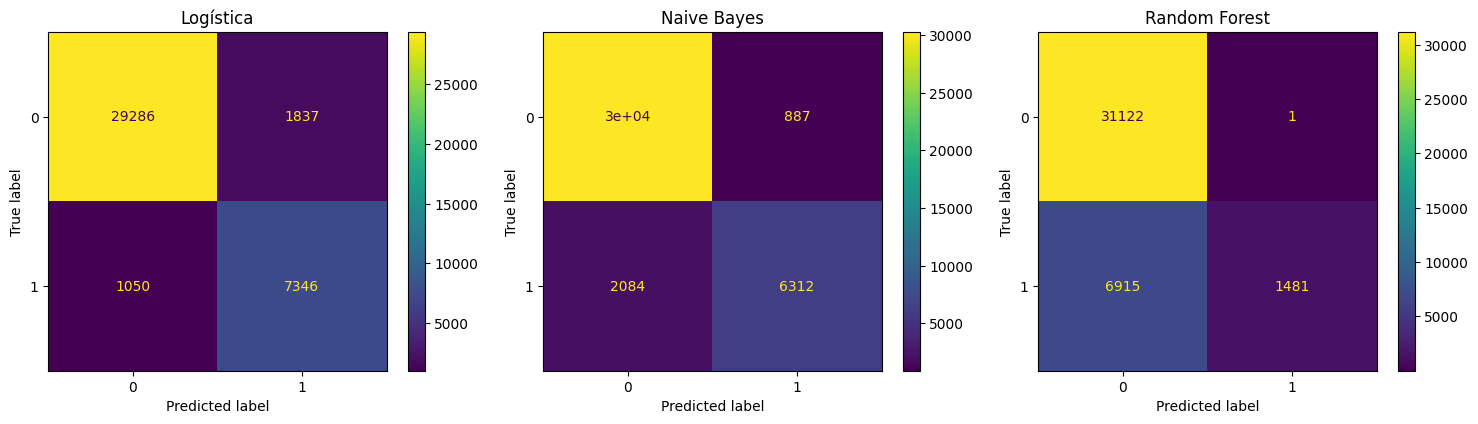

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Logística": y_pred_lr,
    "Naive Bayes": y_pred_nb,
    "Random Forest": y_pred_rf
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nome, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax)
    ax.set_title(nome)

plt.tight_layout()
plt.show()

**Regressão Logística**


*   Detecta bem os ofensivos (7346 acertos)
*   Poucos ofensivos passam batido (1050)
*   Equilíbrio muito bom

->  É o modelo mais equilibrado entre detectar conteúdo ofensivo e evitar erros.


**Naive Bayes**


*  Menos falsos positivos (bom)
*  Muitos falsos negativos (2084, ruim)
*  Deixa passar muito conteúdo ofensivo

->  É mais conservador, mas falha em identificar parte relevante dos textos ofensivos.

**Random Forest**


*   Quase não erra não-erra (1)
*   Mas praticamente não detecta ofensivos

-> O modelo apresenta viés extremo para a classe majoritária, falhando em detectar conteúdo ofensivo







In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados = []

for nome, y_pred in models.items():
  resultados.append({
      "Modelo": nome,
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision (classe 1)": precision_score(y_test, y_pred),
      "Recall (classe 1)": recall_score(y_test, y_pred),
      "F1-score": f1_score(y_test, y_pred)
  })

df_resultados = pd.DataFrame(resultados)
print(df_resultados)



          Modelo  Accuracy  Precision (classe 1)  Recall (classe 1)  F1-score
0      Logística  0.926947              0.799956           0.874940  0.835770
1    Naive Bayes  0.924821              0.876788           0.751787  0.809490
2  Random Forest  0.824996              0.999325           0.176394  0.299858


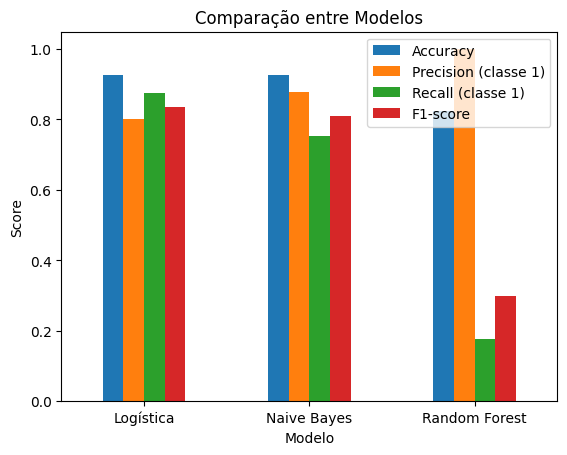

In [ ]:
df_resultados.set_index("Modelo").plot(kind="bar")
plt.title("Comparação entre Modelos")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

**Regressão Logística**


*   Todas as métricas equilibradas
*   Melhor barra geral

-> Modelo mais confiável


**Naive Bayes**


*  Precision boa
*  Recall caiu

->  Perde ofensivos

**Random Forest**


*   Precision altíssima (quase 1)
*   Recall muito baixo

-> Quase nunca diz que algo é ofensivo



